### Importación del dataset. (Usar pip install kagglehub)

Para SO GNU/Linux, debe usar un .venv: 

    python -m venv .venv   
    source .venv/bin/activate   
    python -m pip install --upgrade pip
    pip install kagglehub
    python -m pip install "kagglehub[pandas-datasets]"


Cambiar el kernel de Python al .venv que está dentro de la carpeta y correr.




In [132]:
# ¡Buscar dónde se está ejecutando el Python y cambiar kernel!
import sys
print(sys.executable)

/mnt/hdd/Duoc_DataScience/Programación_DataScience/Examen/.venv/bin/python


In [133]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

import os

file_path = "Credit_Card_Applications.csv"

# Obtener file_path
"""
path = kagglehub.dataset_download("nazishjaveed/credit-card-application")
print("Path to dataset files:", path)
print(os.listdir(path))
"""
# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nazishjaveed/credit-card-application",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head(5)

/tmp/ipykernel_48298/562306904.py:18: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [135]:
df.shape

(690, 16)

In [136]:
df.isnull().sum()

CustomerID    0
A1            0
A2            0
A3            0
A4            0
A5            0
A6            0
A7            0
A8            0
A9            0
A10           0
A11           0
A12           0
A13           0
A14           0
Class         0
dtype: int64

In [137]:
df.duplicated().sum()


np.int64(0)

No tiene nulos ni duplicados. El dataset se encuentra en óptimas condiciones para proseguir.

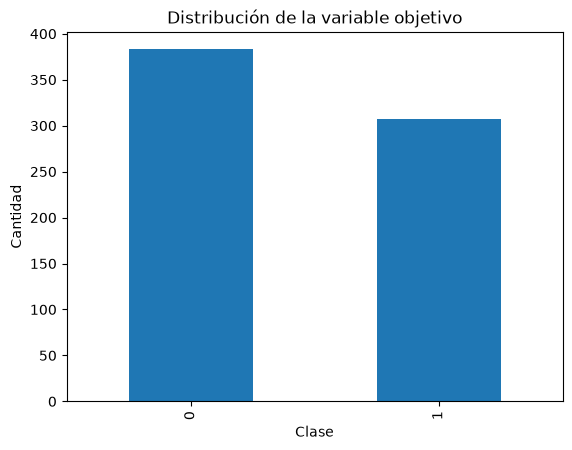

In [138]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

## Distribución de la variable objetivo

El gráfico de barras muestra la cantidad de solicitudes **aprobadas (1)** frente a **rechazadas (0)**. Las clases están relativamente balanceadas (383 vs 307), por lo que no es necesario aplicar técnicas de balanceo (oversampling/undersampling) antes de entrenar los modelos de clasificación.

In [139]:
df["Class"].value_counts()

Class
0    383
1    307
Name: count, dtype: int64

In [140]:
df["Class"].unique()

array([0, 1])

# Distribución de las Variables

Los histogramas muestran la distribución de cada atributo del conjunto de datos.

## Descripción de las variables

| Variable | Descripción |
|----------|-------------|
| CustomerID | Identificador único del solicitante. |
| A1 | Variable binaria (por ejemplo, género o estado del solicitante). |
| A2 | Edad del solicitante. |
| A3 | Monto de deuda o carga financiera. |
| A4 | Categoría asociada al estado civil u otra clasificación demográfica. |
| A5 | Número de dependientes u otra característica familiar. |
| A6 | Nivel educacional o situación laboral. |
| A7 | Historial o puntuación crediticia. |
| A8 | Años de empleo o experiencia laboral. |
| A9 | Variable binaria (por ejemplo, posesión de propiedad o teléfono). |
| A10 | Variable numérica sin descripción oficial en el dataset. |
| A11 | Variable numérica sin descripción oficial en el dataset. |
| A12 | Variable numérica sin descripción oficial en el dataset. |
| A13 | Variable numérica sin descripción oficial en el dataset. |
| A14 | Variable numérica sin descripción oficial en el dataset. |
| Class | Variable objetivo. 1 = Solicitud aprobada, 0 = Solicitud rechazada. |

## Observaciones

- Se analizaron las distribuciones de todas las variables mediante histogramas.
- Algunas variables presentan distribución discreta, mientras que otras son continuas.
- La variable **Class** corresponde a la variable objetivo del modelo de clasificación.

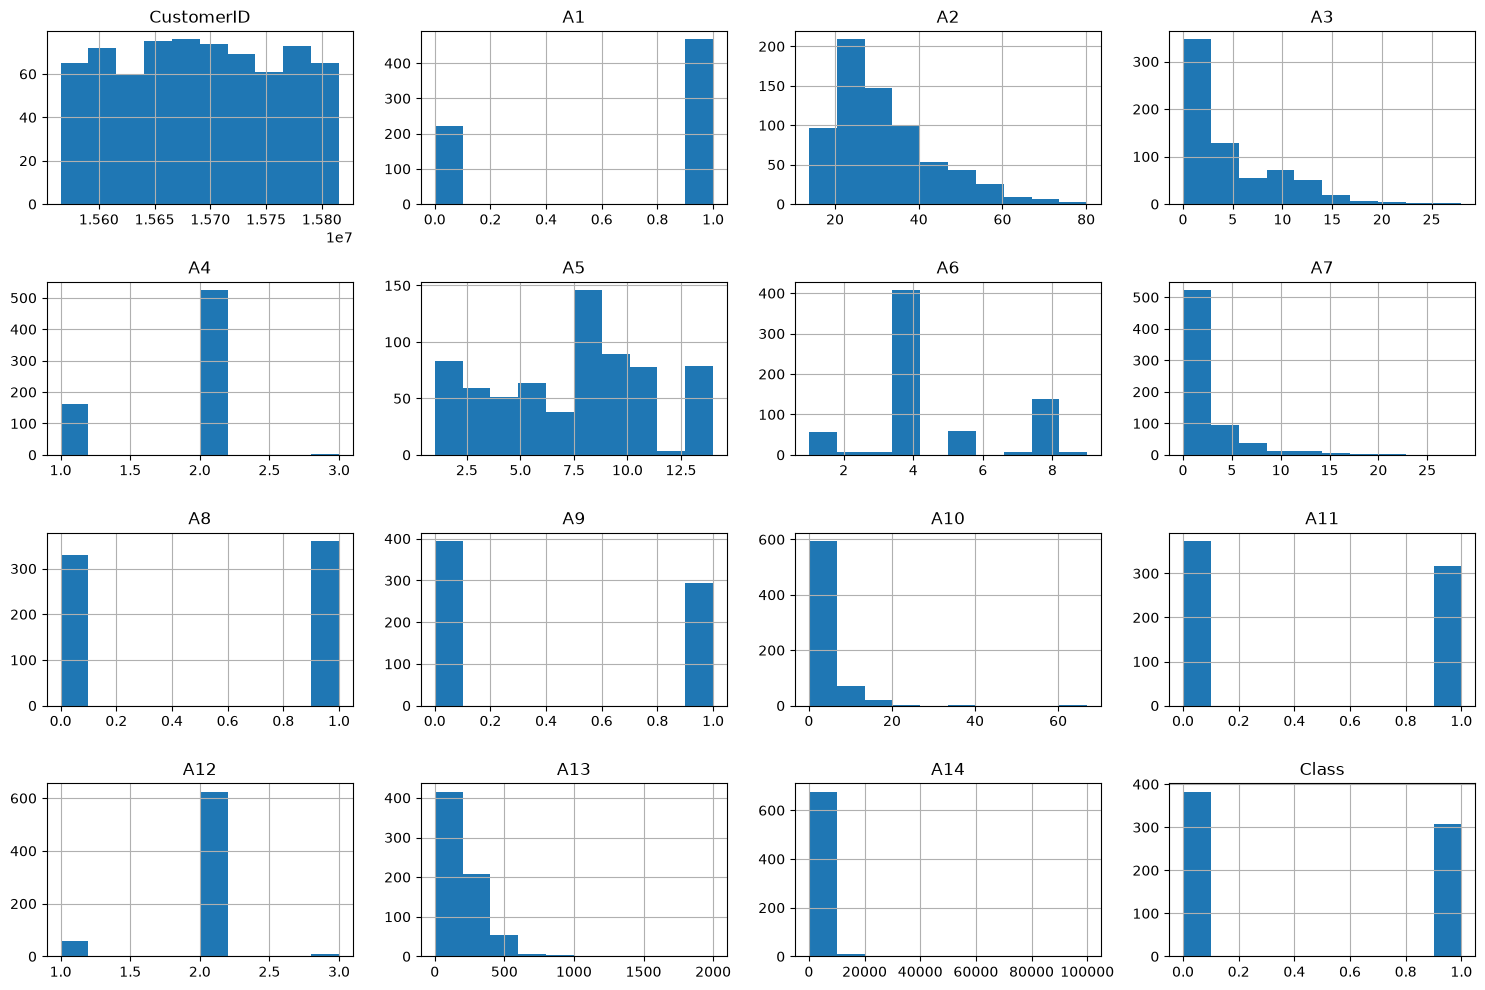

In [141]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Histogramas de variables

Cada histograma resume la distribución individual de un atributo del dataset. Se observan variables numéricas con alta concentración de valores en cero o cercanos a cero (por ejemplo `A3`, `A8`, `A14`), lo que sugiere colas largas (skew) y refuerza la conveniencia de escalar los datos antes de entrenar modelos sensibles a la magnitud de las variables, como Logistic Regression o K-Means.

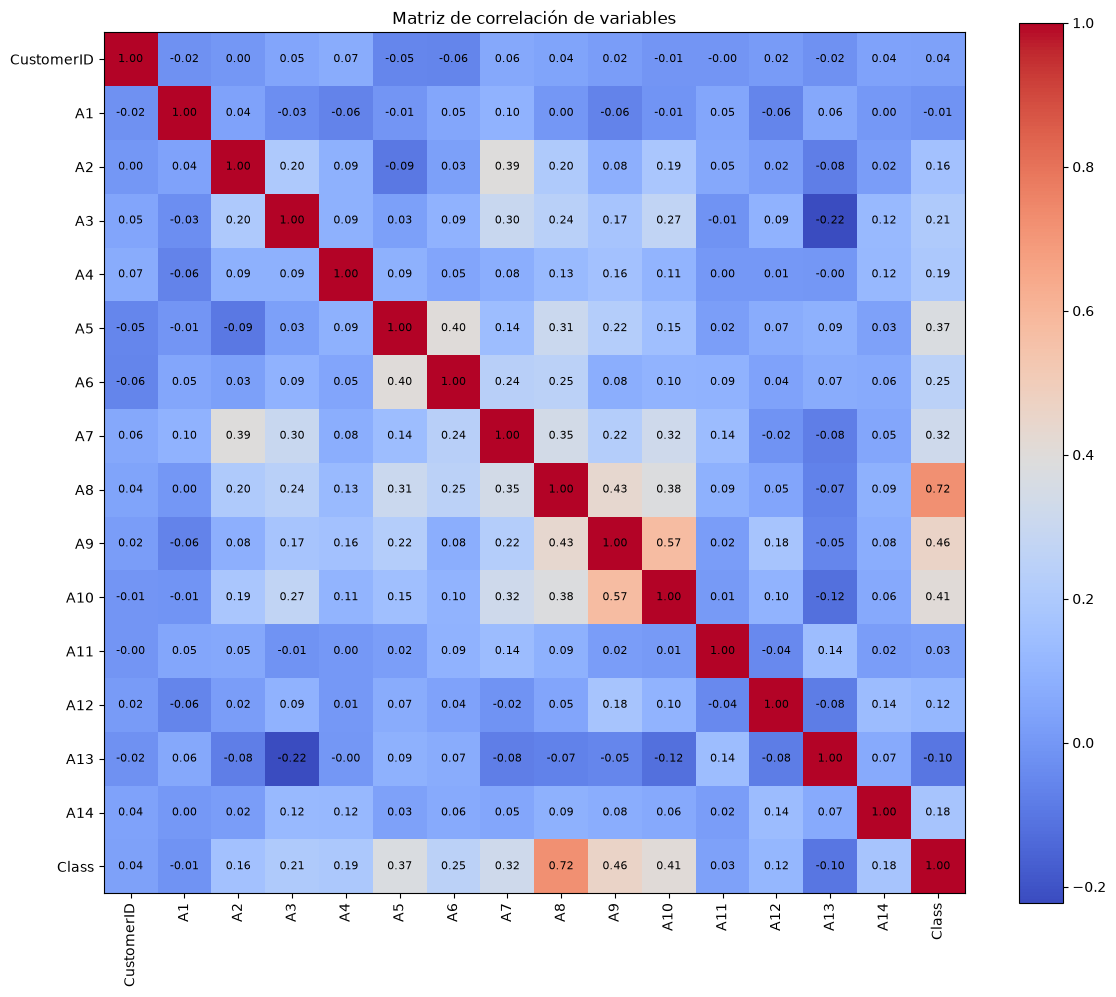

In [142]:
import matplotlib.pyplot as plt
import numpy as np

corr = df.corr()

fig, ax = plt.subplots(figsize=(12,10))

im = ax.imshow(corr, cmap="coolwarm")

# Etiquetas
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

# Escribir el valor de correlación en cada celda
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.colorbar(im)

plt.title("Matriz de correlación de variables")

plt.tight_layout()

plt.show()

## Matriz de correlación

El mapa de calor muestra la correlación lineal entre todas las variables numéricas del dataset. Valores cercanos a **1** o **-1** indican una relación fuerte (directa o inversa); valores cercanos a **0** indican poca o ninguna relación lineal. Esto permite identificar posibles variables redundantes y observar qué atributos se relacionan más con la variable objetivo `Class`.

In [143]:
X = df.drop(
    ["Class","CustomerID"],
    axis=1
)

y = df["Class"]

In [144]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Escalamiento de variables numéricas.
# El scaler se ajusta SOLO con X_train para no filtrar información del set de test.
scaler_clf = StandardScaler()

X_train = scaler_clf.fit_transform(X_train)
X_test = scaler_clf.transform(X_test)

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


models = {

"Logistic Regression":
LogisticRegression(max_iter=1000),

"Decision Tree":
DecisionTreeClassifier(random_state=42),

"Random Forest":
RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

}

In [146]:
from sklearn.metrics import accuracy_score


results={}


for name,model in models.items():

    model.fit(X_train,y_train)

    prediction=model.predict(X_test)

    acc=accuracy_score(
        y_test,
        prediction
    )

    results[name]=acc


results

/mnt/hdd/Duoc_DataScience/Programación_DataScience/Examen/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8333333333333334,
 'Decision Tree': 0.7681159420289855,
 'Random Forest': 0.8043478260869565}

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81        77
           1       0.73      0.89      0.80        61

    accuracy                           0.80       138
   macro avg       0.81      0.81      0.80       138
weighted avg       0.82      0.80      0.80       138



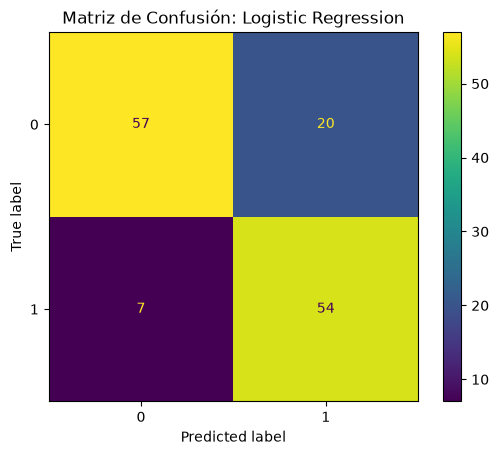

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81        77
           1       0.73      0.89      0.80        61

    accuracy                           0.80       138
   macro avg       0.81      0.81      0.80       138
weighted avg       0.82      0.80      0.80       138



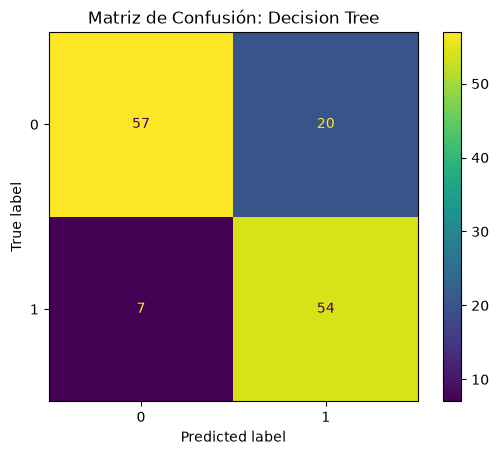

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.89      0.74      0.81        77
           1       0.73      0.89      0.80        61

    accuracy                           0.80       138
   macro avg       0.81      0.81      0.80       138
weighted avg       0.82      0.80      0.80       138



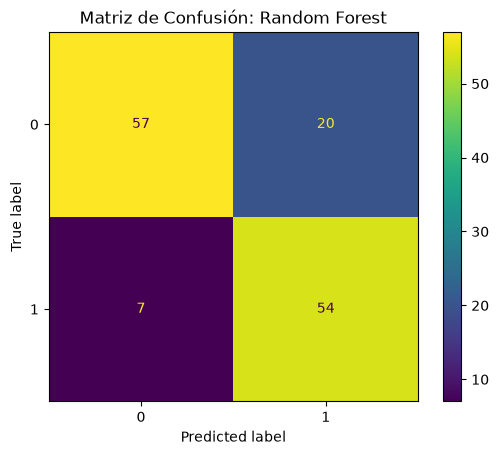

In [147]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    # ... (tu código de fit y predict)
    print(f"--- {name} ---")
    print(classification_report(y_test, prediction))
    
    # Matriz de confusión visual
    cm = confusion_matrix(y_test, prediction)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusión: {name}")
    plt.show()

## Matrices de confusión por modelo

Cada matriz compara las predicciones del modelo contra las clases reales del set de test: la diagonal principal muestra los aciertos (verdaderos positivos y verdaderos negativos), mientras que fuera de la diagonal quedan los errores (falsos positivos y falsos negativos). Junto con el `classification_report`, permiten evaluar no solo el accuracy global, sino también *precision*, *recall* y *f1-score* de cada modelo (Logistic Regression, Decision Tree y Random Forest).

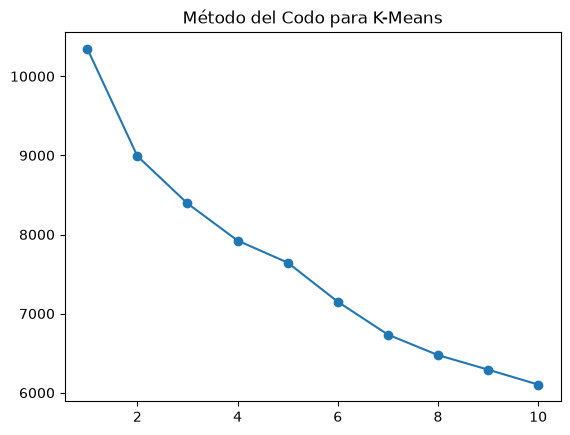

In [148]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Escalar (importante para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('Class', axis=1))

# 2. Encontrar el K óptimo (Método del Codo)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el codo para justificar la elección de K
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para K-Means')
plt.show()

## Método del codo

El gráfico muestra la inercia (suma de distancias al cuadrado dentro de cada cluster) para distintos valores de **K**. El "codo" de la curva —el punto donde la reducción de inercia empieza a ser marginal— indica el número óptimo de clusters a usar en K-Means, evitando tanto el subajuste (pocos clusters) como el sobreajuste (demasiados clusters sin ganancia real).

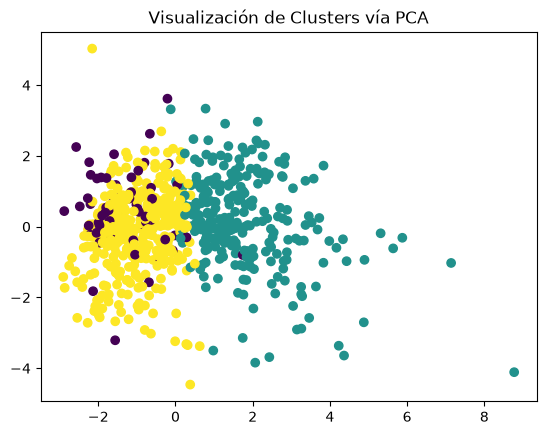

In [149]:
from sklearn.decomposition import PCA

# Reducción a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Visualización
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('Visualización de Clusters vía PCA')
plt.show()

## Visualización de clusters vía PCA

Como los datos originales tienen muchas dimensiones, se usa **PCA** para reducirlos a 2 componentes principales y poder graficarlos en un plano. Cada punto es un cliente y su color representa el cluster asignado por K-Means (con K=3). Esto permite visualizar de forma aproximada qué tan bien separados quedan los grupos encontrados por el modelo de clustering.

In [ ]:
import joblib

# Guardamos los modelos que entrenaste
# Nota: Si entrenaste varios, puedes guardar el diccionario entero
joblib.dump(models, 'models_dict.joblib')

# Guardamos el objeto PCA y el Escalador de clustering (¡Vital para que el dashboard procese igual que el entrenamiento!)
joblib.dump(pca, 'pca.joblib')
joblib.dump(scaler, 'scaler.joblib')

# Escalador usado para los modelos de clasificación (A1-A14, sin CustomerID)
joblib.dump(scaler_clf, 'scaler_clf.joblib')